# Batch1 학습·검증 및 최적 모델 선택

Batch1만 사용한다. 먼저 학습 75%와 검증 25%로 분리하고, 후보 모델 비교와 튜닝은 학습 데이터 내부 4-fold CV에서만 진행한다. CV MAE가 가장 낮은 모델을 선택한 뒤 검증 데이터로 한 번 평가한다. Batch2는 읽거나 사용하지 않는다.

In [1]:
# 현재 Jupyter 커널에 없는 패키지만 설치합니다.
import importlib.util, subprocess, sys
required = {'numpy': 'numpy', 'pandas': 'pandas', 'sklearn': 'scikit-learn', 'matplotlib': 'matplotlib', 'joblib': 'joblib'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    print('설치 완료:', ', '.join(missing))
else:
    print('필요한 패키지가 모두 설치되어 있습니다.')


필요한 패키지가 모두 설치되어 있습니다.


## 1. Batch1 준비 및 학습·검증 분리

Batch1을 수명 사분위 비율이 유지되도록 학습 75%와 검증 25%로 나눈다. 이 단계에서는 Batch2를 사용하지 않는다.

In [2]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import clone

warnings.filterwarnings('ignore')
ROOT = Path.cwd()
OUT = ROOT / 'output' / 'batch1_train_validation'
OUT.mkdir(parents=True, exist_ok=True)

batch1 = pd.read_csv(ROOT / 'output/model/batch1_features.csv')
excluded = ['batch', 'cell_id', 'cycle_life', 'charging_policy', 'policy_parsed', 'early_qd_excluded']
features = [c for c in batch1.columns if c not in excluded]
X, y = batch1[features], batch1['cycle_life']
strata = pd.qcut(y, q=4, labels=False, duplicates='drop')
train_idx, valid_idx = train_test_split(np.arange(len(batch1)), test_size=0.25, random_state=42, stratify=strata)
X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
print(f'Batch1 전체 {len(batch1)}개 / 학습 {len(train_idx)}개 / 검증 {len(valid_idx)}개')



Batch1 전체 46개 / 학습 34개 / 검증 12개


## 2. Batch1 학습 데이터에서 후보 모델 비교

학습 데이터 34개 안에서만 4-fold CV와 하이퍼파라미터 탐색을 수행한다. 검증 데이터 12개는 후보 선택에 사용하지 않는다.

In [3]:
model_specs = {
    'Dummy': (DummyRegressor(), {'model__strategy': ['mean', 'median']}),
    'Ridge': (Ridge(), {'model__alpha': [0.1, 1, 10, 100, 1000]}),
    'ElasticNet': (ElasticNet(max_iter=200000, tol=1e-3), {'model__alpha': [0.1, 1, 10, 100], 'model__l1_ratio': [0.1, 0.5, 0.9]}),
    'RandomForest': (RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1), {'model__max_depth': [None, 3, 5], 'model__min_samples_leaf': [1, 2, 4], 'model__max_features': [0.5, 1.0]}),
    'ExtraTrees': (ExtraTreesRegressor(n_estimators=500, random_state=42, n_jobs=-1), {'model__max_depth': [None, 3, 5], 'model__min_samples_leaf': [1, 2, 4], 'model__max_features': [0.5, 1.0]}),
    'GradientBoosting': (GradientBoostingRegressor(random_state=42), {'model__n_estimators': [50, 100, 200], 'model__learning_rate': [0.03, 0.05, 0.1], 'model__max_depth': [1, 2], 'model__min_samples_leaf': [2, 4]}),
}
inner_cv = KFold(n_splits=4, shuffle=True, random_state=42)
rows, searches = [], {}
for name, (estimator, grid) in model_specs.items():
    pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler()), ('model', estimator)])
    search = GridSearchCV(pipeline, grid, scoring='neg_mean_absolute_error', cv=inner_cv, n_jobs=1)
    search.fit(X_train, y_train)
    rows.append({'model': name, 'train_cv_mae': -search.best_score_, 'train_cv_mae_std': search.cv_results_['std_test_score'][search.best_index_], 'best_parameters': json.dumps(search.best_params_, ensure_ascii=False)})
    searches[name] = search
comparison = pd.DataFrame(rows).sort_values('train_cv_mae').reset_index(drop=True)
display(comparison.round(2))



,model,train_cv_mae,train_cv_mae_std,best_parameters
0,GradientBoosting,75.71,6.67,"{""model__learning_rate"": 0.05, ""model__max_dep..."
1,ExtraTrees,81.47,17.18,"{""model__max_depth"": null, ""model__max_feature..."
2,RandomForest,86.40,15.90,"{""model__max_depth"": null, ""model__max_feature..."
3,ElasticNet,143.58,17.73,"{""model__alpha"": 100, ""model__l1_ratio"": 0.1}"
4,Dummy,148.32,20.02,"{""model__strategy"": ""mean""}"
5,Ridge,220.61,148.43,"{""model__alpha"": 1000}"


## 3. 선택 모델의 Batch1 검증

학습 CV MAE가 가장 낮은 모델을 고정하고, 따로 보관한 Batch1 검증 데이터로 평가한다. 여기까지가 기존 Batch1 학습·검증 단계다.

In [4]:
selected_name = comparison.loc[0, 'model']
selected_model = searches[selected_name].best_estimator_
train_cv_mape_scores = -cross_val_score(
    selected_model, X_train, y_train, cv=inner_cv,
    scoring='neg_mean_absolute_percentage_error', n_jobs=1,
) * 100
train_cv_mape = train_cv_mape_scores.mean()
valid_pred = selected_model.predict(X_valid)
validation_metrics = pd.Series({
    'MAE': mean_absolute_error(y_valid, valid_pred),
    'MAPE (%)': mean_absolute_percentage_error(y_valid, valid_pred) * 100,
    'RMSE': np.sqrt(mean_squared_error(y_valid, valid_pred)),
    'R2': r2_score(y_valid, valid_pred),
}, name='validation')
display(validation_metrics.round(2).to_frame())

comparison.to_csv(OUT / 'candidate_model_comparison.csv', index=False)
validation_predictions = batch1.iloc[valid_idx][['cell_id', 'charging_policy', 'cycle_life']].copy()
validation_predictions['predicted_cycle_life'] = valid_pred
validation_predictions['absolute_error'] = np.abs(y_valid.to_numpy() - valid_pred)
validation_predictions.to_csv(OUT / 'validation_predictions.csv', index=False)
print('선택 모델:', selected_name)
print('최적 설정:', searches[selected_name].best_params_)



,validation
MAE,99.43
MAPE (%),12.81
RMSE,120.21
R2,0.54


선택 모델: GradientBoosting
최적 설정: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}


---

# Batch2 최종 테스트

아래부터 새로 추가한 테스트 단계다. Batch1 검증 결과로 모델 종류와 설정을 확정한 뒤, Batch1 전체 46개로 재학습하고 Batch2에 한 번 적용한다. Batch2 점수로 모델을 다시 고르지 않는다.

In [5]:
# Batch1에서 선택을 마친 모델을 Batch1 전체로 재학습한 뒤 Batch2를 최종 테스트한다.
batch2 = pd.read_csv(ROOT / 'output/model/batch2_features.csv')
test_mask = batch2['cycle_life'].notna()
X_test = batch2.loc[test_mask, features]
y_test = batch2.loc[test_mask, 'cycle_life']
final_model = clone(selected_model)
final_model.fit(X, y)
test_pred = final_model.predict(X_test)
test_metrics = pd.Series({
    'MAE': mean_absolute_error(y_test, test_pred),
    'MAPE (%)': mean_absolute_percentage_error(y_test, test_pred) * 100,
    'RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
    'R2': r2_score(y_test, test_pred),
}, name='Batch2 test')
display(test_metrics.round(2).to_frame())

joblib.dump(selected_model, OUT / 'selected_model_train_only.joblib')
joblib.dump(final_model, OUT / 'final_model_batch1_all.joblib')
test_predictions = batch2[['batch', 'cell_id', 'charging_policy', 'cycle_life']].copy()
test_predictions['predicted_cycle_life'] = final_model.predict(batch2[features])
test_predictions['absolute_error'] = (test_predictions['cycle_life'] - test_predictions['predicted_cycle_life']).abs()
test_predictions.to_csv(OUT / 'batch2_test_predictions.csv', index=False)
print(f'Batch2 전체 {len(batch2)}개 / 성능 평가 {test_mask.sum()}개 / 정답 없음 {(~test_mask).sum()}개')

# 요청한 회귀 성능 보고 형식
paper_target_mape = 9.1
performance_report = pd.DataFrame([
    {'구분': 'Train (Batch 1 CV)', 'MAPE (%)': train_cv_mape, '비고': 'Batch 1 학습 셀 내부 4-fold CV 평균'},
    {'구분': 'Valid (Batch 1 Hold-out)', 'MAPE (%)': validation_metrics['MAPE (%)'], '비고': '모델 선택에 사용하지 않은 Batch 1 셀'},
    {'구분': 'Test (Batch 2)', 'MAPE (%)': test_metrics['MAPE (%)'], '비고': f'정답이 있는 {int(test_mask.sum())}개 셀 최종 평가'},
    {'구분': 'Gap (Train-Valid)', 'MAPE (%)': validation_metrics['MAPE (%)'] - train_cv_mape, '비고': '(+) : 과적합 의심'},
    {'구분': 'Gap (Valid-Test)', 'MAPE (%)': test_metrics['MAPE (%)'] - validation_metrics['MAPE (%)'], '비고': '(+) : 배치 간 일반화 저하 의심'},
    {'구분': 'Gap (Target-Test)', 'MAPE (%)': test_metrics['MAPE (%)'] - paper_target_mape, '비고': 'Target : 원논문 9.1%'},
])
display(performance_report.round(2))
performance_report.to_csv(OUT / 'performance_report.csv', index=False)


,Batch2 test
MAE,323.25
MAPE (%),67.04
RMSE,350.26
R2,-1.55


Batch2 전체 47개 / 성능 평가 39개 / 정답 없음 8개


,구분,MAPE (%),비고
0,Train (Batch 1 CV),9.55,Batch 1 학습 셀 내부 4-fold CV 평균
1,Valid (Batch 1 Hold-out),12.81,모델 선택에 사용하지 않은 Batch 1 셀
2,Test (Batch 2),67.04,정답이 있는 39개 셀 최종 평가
3,Gap (Train-Valid),3.26,(+) : 과적합 의심
4,Gap (Valid-Test),54.22,(+) : 배치 간 일반화 저하 의심
5,Gap (Target-Test),57.94,Target : 원논문 9.1%


## 모델 성능 보고

- **Train (Batch 1 CV):** Batch1 학습 분할 안의 4-fold CV 평균 성능이다.
- **Valid (Batch 1 Hold-out):** 처음부터 분리해 모델 선택에 사용하지 않은 Batch1 셀의 성능이다. 셀 단위 분리를 사용해 같은 배터리의 사이클 정보가 학습과 검증에 동시에 들어가지 않게 했다.
- **Test (Batch 2):** 모델과 설정을 확정한 뒤 실시한 최종 배치 평가다.
- **Gap (Train-Valid):** 양수이면 학습 내부 성능보다 hold-out 오차가 커진 것이다.
- **Gap (Valid-Test):** 양수이면 Batch2에서 일반화 성능이 낮아진 것이다.
- **Gap (Target-Test):** 원논문 회귀 MAPE 9.1%와 이번 Batch2 MAPE의 차이다. 데이터 분할과 피처가 완전히 같지 않으므로 직접 재현 점수로 단정하지 않는다.

| 구분 | MAPE (%) | 비고 |
|---|---:|---|
| Train (Batch 1 CV) | 9.55 | Batch 1 학습 셀 내부 4-fold CV 평균 |
| Valid (Batch 1 Hold-out) | 12.81 | 모델 선택에 사용하지 않은 Batch 1 셀 |
| Test (Batch 2) | 67.04 | 정답이 있는 39개 셀 최종 평가 |
| Gap (Train-Valid) | 3.26 | (+) : 과적합 의심 |
| Gap (Valid-Test) | 54.22 | (+) : 배치 간 일반화 저하 의심 |
| Gap (Target-Test) | 57.94 | Target : 원논문 9.1% |

## 성능 시각화



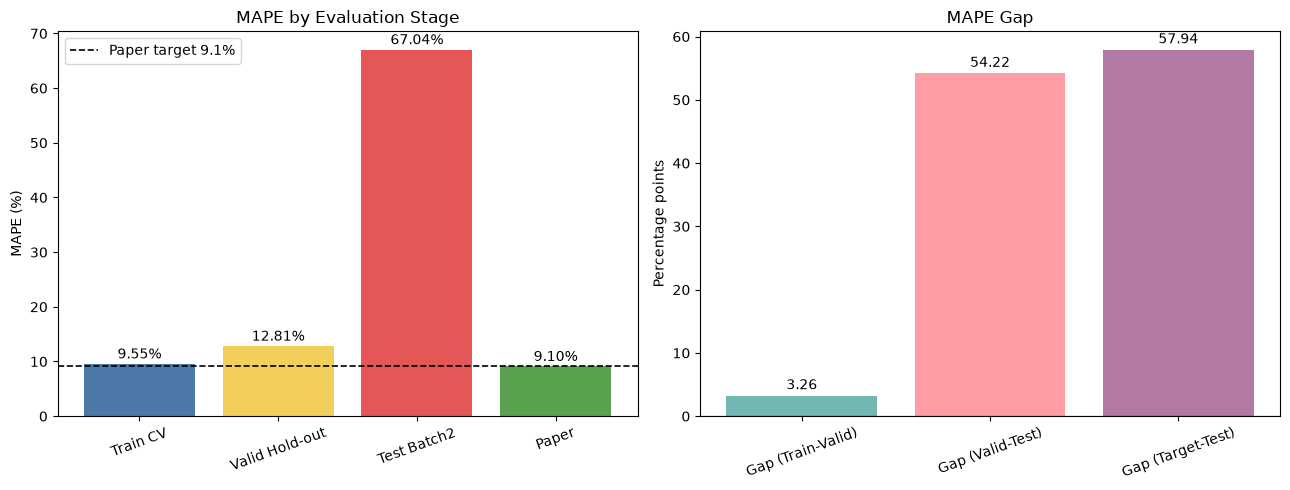

In [6]:
# Train·Valid·Test MAPE와 Gap 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

score_rows = performance_report.iloc[:3]
score_labels = ['Train CV', 'Valid Hold-out', 'Test Batch2', 'Paper']
score_values = [*score_rows['MAPE (%)'], 9.1]
bars = axes[0].bar(
    score_labels, score_values,
    color=['#4C78A8', '#F2CF5B', '#E45756', '#59A14F']
)
axes[0].axhline(9.1, color='black', linestyle='--', linewidth=1.2, label='Paper target 9.1%')
axes[0].set_title('MAPE by Evaluation Stage')
axes[0].set_ylabel('MAPE (%)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()
for bar, value in zip(bars, score_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.2f}%', ha='center')

gap_rows = performance_report.iloc[3:]
gap_bars = axes[1].bar(
    gap_rows['구분'], gap_rows['MAPE (%)'],
    color=['#72B7B2', '#FF9DA6', '#B279A2']
)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('MAPE Gap')
axes[1].set_ylabel('Percentage points')
axes[1].tick_params(axis='x', rotation=20)
for bar, value in zip(gap_bars, gap_rows['MAPE (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.savefig(OUT / 'performance_mape_chart.png', dpi=160, bbox_inches='tight')
plt.show()


왼쪽 그래프는 Train CV·Valid Hold-out·Test Batch2와 논문 MAPE 9.1%를 비교한다. 오른쪽 그래프는 단계 사이의 MAPE 차이를 보여준다.

## 분석 결과

Batch1 46개 셀을 수명 사분위 비율이 유지되도록 학습 34개와 검증 12개로 나눴다. 검증 셀은 후보 선택과 하이퍼파라미터 조정에 사용하지 않았다.

학습 데이터 내부 4-fold CV에서 `GradientBoosting`의 MAE가 75.7사이클로 가장 낮았다. 선택된 설정은 `{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}`이다. 이 모델을 학습 데이터에 적합한 뒤 처음 분리해 둔 검증 데이터에 적용했다. 검증 MAE는 99.4사이클, MAPE는 12.8%, RMSE는 120.2사이클, R²는 0.536이다.

모델 설정을 고정한 뒤 Batch1 전체 46개로 다시 학습해 Batch2를 테스트했다. 정답이 있는 39개 셀의 테스트 MAE는 323.3사이클, MAPE는 67.0%, RMSE는 350.3사이클, R²는 -1.550이다. 정답이 없는 8개 셀은 예측값만 저장하고 성능 계산에서는 제외했다.

Batch2 MAPE는 원논문의 9.1%보다 57.9%p 높고, 수치상 약 7.4배다. 다만 논문과 이번 분석은 데이터 분할과 피처 구성이 완전히 같지 않으므로 같은 실험의 우열이나 재현 성공 여부로 해석하지 않는다.

검증 표본이 12개로 작아 분할에 따라 수치가 달라질 수 있다. Batch2 점수는 모델 선택이나 설정 변경에 사용하지 않았다.

산출물은 `output/batch1_train_validation/`에 저장된다. `selected_model_train_only.joblib`은 학습 분할 34개로 검증 성능을 계산한 모델이다. `final_model_batch1_all.joblib`은 설정 확정 후 Batch1 전체 46개로 재학습해 Batch2 테스트에 사용한 최종 모델이다.